# Subtask 1 - Encoder-Only Transformers for Relational Reasoning

## By Abhisek Mohapatra

In [1]:
# importing libraries
import torch
from torch import nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
dataset = pd.read_csv("./ranking_dataset.csv")

dataset.head()

,val_0,val_1,val_2,val_3,val_4,val_5,val_6,val_7,val_8,val_9,rank_0,rank_1,rank_2,rank_3,rank_4,rank_5,rank_6,rank_7,rank_8,rank_9
0,542,67,876,414,26,335,620,924,950,113,5,1,7,4,0,3,6,8,9,2
1,378,14,210,954,231,572,315,295,567,706,5,0,1,9,2,7,4,3,6,8
2,749,876,73,111,899,213,541,769,287,219,6,8,0,1,9,2,5,7,4,3
3,372,880,475,329,733,564,739,376,632,10,2,9,4,1,7,5,8,3,6,0
4,186,822,577,519,707,123,143,294,693,677,2,9,5,4,8,0,1,3,7,6


In [4]:
len(dataset)

10000

In [5]:
from torch.utils.data import Dataset,DataLoader,random_split

class NumArrayDataset(Dataset):
    """
    Dataset for model
    
    One-hot encoding is done for the ranks and the input as in the values are normalised
    """
    def __init__(self,data):
        self.data = np.array(data,dtype = "int")
        self.x = torch.Tensor(self.data[:,:10])
        self.y = self.data[:,10:]

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self,i):
        self.x[i] -= self.x[i].mean()
        self.x[i] /= self.x[i].std()
        return (self.x[i],self.y[i])
        
    

In [6]:
dataset_trh = NumArrayDataset(dataset)
print(dataset_trh[0])

(tensor([ 0.1557, -1.1821,  1.0964, -0.2048, -1.2975, -0.4273,  0.3754,  1.2316,
         1.3049, -1.0525]), array([5, 1, 7, 4, 0, 3, 6, 8, 9, 2]))


# Making a MLP for predicting the order

In [7]:
valid_ratio = .1
test_ratio = .1

test_size = int(test_ratio*len(dataset_trh))
valid_size = int(valid_ratio*len(dataset_trh))
training_size = len(dataset_trh) - test_size - valid_size


(train_dataset, test_dataset, valid_dataset) = random_split(dataset_trh, [training_size,test_size,valid_size])

In [8]:
train_data = DataLoader(train_dataset, batch_size=64)
valid_data = DataLoader(valid_dataset, batch_size=4096)

In [9]:
class MLPPredictor(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Linear(10,128),
            torch.nn.ReLU(),
            torch.nn.Linear(128,256),
            torch.nn.ReLU(),
            torch.nn.Linear(256,100)
        )

    def forward(self,x):
        return self.model(x).reshape(-1,10,10)
    

In [11]:
max_epochs = 100
learning_rate = 3e-3

model = MLPPredictor()
model.to(device)
loss_fn = nn.CrossEntropyLoss()

opt = torch.optim.AdamW(model.parameters(),lr = learning_rate)

accuracy = []
losses = []
model.train()
for i in range(max_epochs):
    s = 0
    for (x,y) in train_data:
        y = y.to(device)
        x = x.to(device)
        pred = model(x)
        loss = loss_fn(pred,y)
        losses.append(loss.item())
        loss.backward()
        s+=loss.item()
        opt.step()
        opt.zero_grad()
    with torch.no_grad():
        total = 0
        for (x,y) in valid_data:
            y = y.to(device)
            x = x.to(device)
            pred = model(x).transpose(-1,-2)
            pred = torch.argmax(pred,dim=-1)
            total += (y == pred).reshape(-1).sum().cpu().item() 
            accuracy.append(total/valid_size/10)
        if (i%10 == 0):
            print(total/valid_size/10)


0.4303
0.5671
0.61
0.63
0.6384000000000001
0.6436
0.6454
0.6486
0.6522
0.6547


In [12]:
model.eval()

total = 0
total2 = 0
total3 = 0
total4 = 0
avg =0
with torch.no_grad():
    for (x,y) in test_data:
        y = y.to(device)
        x = x.to(device)
        pred = model(x).transpose(-1,-2)
        pred = torch.argmax(pred,dim=-1)
        z = (y == pred).reshape(-1)
        total+=z.sum()
        z = z.reshape(-1,10)
        total2 += torch.where(torch.sum(z,dim = -1) == 10, 1,0).sum()
        total3 += torch.where(abs(torch.sum(z,dim = -1)-10)<=1, 1,0).sum()
        total4 += torch.where(abs(torch.sum(z,dim = -1)-10)<=2, 1,0).sum()
        avg += abs(torch.sum(z,dim = -1)-10).sum()

print("Test Accuracy (%):",total/test_size/10*100)
print("Full sequence correct (%):",total2/test_size*100)
print("Atmost 1 incorect sequence correct (%):",total3/test_size*100)
print("Atmost 2 incorect sequence correct (%):",total4/test_size*100)
print("Average no of rank predicted incorect in a sequence :",avg/test_size)

NameError: name 'test_data' is not defined

In [ ]:
with torch.no_grad():
    for i in range(4,50,5):
        (x,y) = test_dataset[i]
        x = x.to(device)
        pred = model(x).transpose(-1,-2)
        pred = pred.reshape(10,10).cpu()
        pred = torch.argmax(pred,dim=-1).reshape(-1)
        print(f"{i+1} testcase")
        print("x : ",x.cpu().numpy())
        print("pred : ",pred.numpy())
        print("true : ",y)


# Testing RNN and LSTM
## To see if memory helps

In [13]:
from torch.utils.data import Dataset,DataLoader,random_split

class NumArrayDataset(Dataset):
    """
    Dataset for model
    
    One-hot encoding is done for the ranks and the input as in the values are normalised
    """
    def __init__(self,data):
        self.data = np.array(data,dtype = "int")
        self.x = torch.Tensor(self.data[:,:10])
        self.y = torch.LongTensor(self.data[:,10:])

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self,i):
        self.x[i] -= self.x[i].mean()
        self.x[i] /= self.x[i].std()
        return (self.x[i],self.y[i])
        
    

In [14]:
dataset_trh = NumArrayDataset(dataset)
dataset_trh[0]

(tensor([ 0.1557, -1.1821,  1.0964, -0.2048, -1.2975, -0.4273,  0.3754,  1.2316,
          1.3049, -1.0525]),
 tensor([5, 1, 7, 4, 0, 3, 6, 8, 9, 2]))

In [15]:
valid_ratio = .1
test_ratio = .1

test_size = int(test_ratio*len(dataset_trh))
valid_size = int(valid_ratio*len(dataset_trh))
training_size = len(dataset_trh) - test_size - valid_size

gen1 = torch.Generator().manual_seed(42)
(train_dataset, test_dataset, valid_dataset) = random_split(dataset_trh, [training_size,test_size,valid_size],generator=gen1)

In [33]:
train_data = DataLoader(train_dataset, batch_size=64)
valid_data = DataLoader(valid_dataset, batch_size=4096)
test_data = DataLoader(test_dataset, batch_size=4096)

In [17]:
class SimpleRNNPredictor(nn.Module):
    def __init__(self,history,device):
        super().__init__()
        self.history = history
        self.device = device
        self.W_y = nn.Sequential(
            nn.Linear(self.history+1,10),
        )
        self.W_o = nn.Sequential(
            nn.Linear(10*10,10*10),
        )
        self.W_h = nn.Sequential(
            nn.Linear(self.history+1,self.history),
            nn.Tanh()
        )

    def forward(self,x):
        h = torch.randn(len(x),self.history).to(self.device)
        outputs = []
        for i  in range(10):
            combined_inputs = torch.concat([h,x[:,i:i+1]],dim = -1)
            o = self.W_y(combined_inputs)
            outputs.append(o)
            h =self.store(combined_inputs)
        y = self.W_o(torch.concat(outputs,dim=-1)).reshape(-1,10,10).transpose(-1,-2)
        return y

    def store(self,combined_inputs):
        return self.W_h(combined_inputs)

In [18]:
max_epochs = 100
learning_rate = 2e-3

#device = "cuda:0" if torch.cuda.is_available() else "cpu"
device = "cpu"
model = SimpleRNNPredictor(128,device)
model.to(device)
loss_fn = nn.CrossEntropyLoss()

opt = torch.optim.AdamW(model.parameters(),lr = learning_rate)
accuracy = []
losses = []
model.train()
for i in range(max_epochs):
    s = 0
    for (x,y) in train_data:
        y = y.to(device)
        x = x.to(device)
        pred = model(x)
        loss = loss_fn(pred,y)
        losses.append(loss.item())
        loss.backward()
        s+=loss.item()
        opt.step()
        opt.zero_grad()
    with torch.no_grad():
        total = 0
        for (x,y) in valid_data:
            y = y.to(device)
            x = x.to(device)
            pred = model(x).transpose(-1,-2)
            pred = torch.softmax(pred,dim=-1)
            pred = torch.argmax(pred,dim=-1)
            total += (y == pred).reshape(-1).sum().cpu().item() 
            accuracy.append(total/valid_size/10) 
        if (i%10 == 0):
            print(total/valid_size/10)

0.3641
0.5636
0.613
0.6503
0.6771
0.6994
0.7138
0.7232999999999999
0.7261
0.727


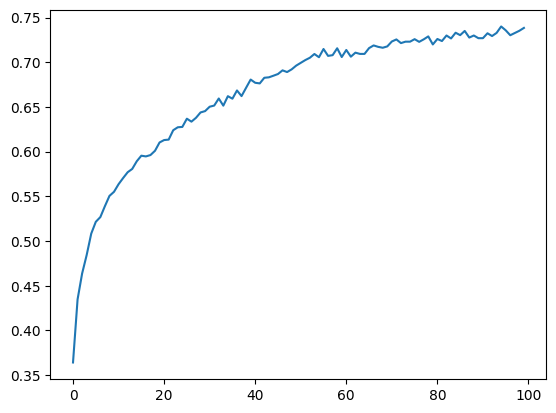

In [20]:
plt.plot(accuracy)

In [21]:
model.eval()

total = 0
total2 = 0
total3 = 0
total4 = 0
avg =0
with torch.no_grad():
    for (x,y) in test_data:
        y = y.to(device)
        x = x.to(device)
        pred = model(x).transpose(-1,-2)
        pred = torch.softmax(pred,dim=-1)
        pred = torch.argmax(pred,dim=-1)
        z = (y == pred).reshape(-1)
        total+=z.sum()
        z = z.reshape(-1,10)
        total2 += torch.where(torch.sum(z,dim = -1) == 10, 1,0).sum()
        total3 += torch.where(abs(torch.sum(z,dim = -1)-10)<=1, 1,0).sum()
        total4 += torch.where(abs(torch.sum(z,dim = -1)-10)<=2, 1,0).sum()
        avg += abs(torch.sum(z,dim = -1)-10).sum()

print("Test Accuracy (%):",total/test_size/10*100)
print("Full sequence correct (%):",total2/test_size*100)
print("Atmost 1 incorect sequence correct (%):",total3/test_size*100)
print("Atmost 2 incorect sequence correct (%):",total4/test_size*100)
print("Average no of rank predicted incorect in a sequence :",avg/test_size)

Test Accuracy (%): tensor(72.8500)
Full sequence correct (%): tensor(4.5000)
Atmost 1 incorect sequence correct (%): tensor(21.2000)
Atmost 2 incorect sequence correct (%): tensor(48.1000)
Average no of rank predicted incorect in a sequence : tensor(2.7150)


In [22]:
with torch.no_grad():
    for i in range(4,50,5):
        (x,y) = test_dataset[i]
        x = x.to(device).reshape(1,10)
        pred = model(x).transpose(-1,-2)
        pred = pred.reshape(10,10).cpu()
        pred = torch.argmax(pred,dim=-1).reshape(-1)
        print(f"{i+1} testcase")
        print("x : ",x.cpu().numpy())
        print("pred : ",pred.numpy())
        print("true : ",y)

5 testcase
x :  [[-0.74125314  1.6795136   0.6961838  -0.679795   -1.0553724   1.3927091
  -1.1714599   0.20451888 -0.44761992  0.12257475]]
pred :  [2 9 7 3 1 8 0 6 4 6]
true :  tensor([2, 9, 7, 3, 1, 8, 0, 6, 4, 5])
10 testcase
x :  [[-0.19773103 -1.0545657   0.07909244  0.5931932  -0.17795794 -0.27682343
   1.7532153  -0.5997842   1.3445711  -1.4632097 ]]
pred :  [5 1 6 7 4 4 9 2 8 0]
true :  tensor([4, 1, 6, 7, 5, 3, 9, 2, 8, 0])
15 testcase
x :  [[-0.7235851  -0.16007073 -0.92367357 -0.4173273   2.2777414  -0.6174158
   0.39119333 -0.02531729 -0.81750417  1.0159594 ]]
pred :  [1 6 1 4 9 3 7 6 1 8]
true :  tensor([2, 5, 0, 4, 9, 3, 7, 6, 1, 8])
20 testcase
x :  [[ 0.9472598  -0.11623449  1.7516979  -1.1933633  -1.1320078   0.6711603
   0.41551265 -0.16736402 -1.2853965   0.10873545]]
pred :  [8 4 9 0 1 7 6 4 1 5]
true :  tensor([8, 4, 9, 1, 2, 7, 6, 3, 0, 5])
25 testcase
x :  [[-0.6227921   0.5958571  -0.81002396  0.5235922  -1.5162493  -1.4012824
   0.5728637   1.3677777   0.51702

In [25]:

class LSTMPredictor(torch.nn.Module):
    def __init__(self,history,cell_size,device):
        super().__init__()
        self.history = history
        self.cell_size = cell_size
        self.device = device
        self.combined_size = self.history+1
        self.W_f = nn.Sequential(
            torch.nn.Linear(self.combined_size,self.cell_size),
            torch.nn.Sigmoid(),
        )
        self.W_i1 = nn.Sequential(
            torch.nn.Linear(self.combined_size,self.cell_size),
            torch.nn.Sigmoid(),
        )
        self.W_i2 = nn.Sequential(
            torch.nn.Linear(self.combined_size,self.cell_size),
            torch.nn.Tanh(),
        )
        self.W_hc = nn.Sequential(
            nn.Linear(self.cell_size,self.history),
            nn.Tanh()
        )
        self.W_hh = nn.Sequential(
            nn.Linear(self.combined_size,self.history),
            nn.Sigmoid()
        )
        self.W_oh = nn.Sequential(
            nn.Linear(self.history+self.cell_size+10,100)
        )

    def forward(self,x):
        h = torch.zeros(len(x),self.history).to(self.device)
        c = torch.zeros(len(x),self.cell_size).to(self.device)
        outputs = []
        for i  in range(10):
            combined_inputs = torch.concat((h,x[:,i:i+1]),dim = 1)

            # forget part
            c= c * self.W_f(combined_inputs)
            # storing info
            c= c + self.W_i1(combined_inputs)*self.W_i2(combined_inputs)
            # getting output
            h = self.W_hh(combined_inputs) * self.W_hc(c)
            outputs.append(h)
        #h = torch.concat(outputs,dim = 1)
        y = self.W_oh(torch.concat((h,c,x),dim = 1))
        return y.reshape(-1,10,10)

In [28]:
max_epochs = 100
learning_rate = 1e-3

#device = "cuda:0" if torch.cuda.is_available() else "cpu"
device = "cpu"
model = LSTMPredictor(64,128,device)
model.to(device)
loss_fn = nn.CrossEntropyLoss()

opt = torch.optim.AdamW(model.parameters(),lr = learning_rate)
accuracy = []
losses = []
model.train()
for i in range(max_epochs):
    s = 0
    for (x,y) in train_data:
        y = y.to(device)
        x = x.to(device)
        pred = model(x)
        loss = loss_fn(pred,y)
        losses.append(loss.item())
        loss.backward()
        s+=loss.item()
        opt.step()
        opt.zero_grad()
    with torch.no_grad():
        total = 0
        for (x,y) in valid_data:
            y = y.to(device)
            x = x.to(device)
            pred = model(x).transpose(-1,-2)
            pred = torch.softmax(pred,dim=-1)
            pred = torch.argmax(pred,dim=-1)
            total += (y == pred).reshape(-1).sum().cpu().item()
            accuracy.append(total/valid_size/10)
        if (i%10 == 0):
            print(total/valid_size/10)


0.20400000000000001
0.526
0.6097
0.6561
0.6819
0.6961999999999999
0.7061
0.7105
0.7069
0.7046


In [29]:

model.eval()

total = 0
total2 = 0
total3 = 0
total4 = 0
avg =0
with torch.no_grad():
    for (x,y) in test_data:
        y = y.to(device)
        x = x.to(device)
        pred = model(x).transpose(-1,-2)
        pred = torch.softmax(pred,dim=-1)
        pred = torch.argmax(pred,dim=-1)
        z = (y == pred).reshape(-1)
        total+=z.sum()
        z = z.reshape(-1,10)
        total2 += torch.where(torch.sum(z,dim = -1) == 10, 1,0).sum()
        total3 += torch.where(abs(torch.sum(z,dim = -1)-10)<=1, 1,0).sum()
        total4 += torch.where(abs(torch.sum(z,dim = -1)-10)<=2, 1,0).sum()
        avg += abs(torch.sum(z,dim = -1)-10).sum()

print("Test Accuracy (%):",total/test_size/10*100)
print("Full sequence correct (%):",total2/test_size*100)
print("Atmost 1 incorect sequence correct (%):",total3/test_size*100)
print("Atmost 2 incorect sequence correct (%):",total4/test_size*100)
print("Average no of rank predicted incorect in a sequence :",avg/test_size)

Test Accuracy (%): tensor(69.3400)
Full sequence correct (%): tensor(3.6000)
Atmost 1 incorect sequence correct (%): tensor(15.7000)
Atmost 2 incorect sequence correct (%): tensor(37.7000)
Average no of rank predicted incorect in a sequence : tensor(3.0660)


In [30]:
with torch.no_grad():
    for i in range(4,50,5):
        (x,y) = test_dataset[i]
        x = x.to(device).reshape(1,10)
        pred = model(x).transpose(-1,-2)
        pred = pred.reshape(10,10).cpu()
        pred = torch.argmax(pred,dim=-1).reshape(-1)
        print(f"{i+1} testcase")
        print("x : ",x.cpu().numpy())
        print("pred : ",pred.numpy())
        print("true : ",y)

5 testcase
x :  [[-0.7412532   1.6795137   0.69618386 -0.6797951  -1.0553725   1.3927093
  -1.17146     0.20451894 -0.44761992  0.1225748 ]]
pred :  [2 9 7 2 2 8 0 6 4 5]
true :  tensor([2, 9, 7, 3, 1, 8, 0, 6, 4, 5])
10 testcase
x :  [[-0.19773103 -1.0545657   0.07909244  0.5931932  -0.17795794 -0.27682343
   1.7532153  -0.5997842   1.3445711  -1.4632097 ]]
pred :  [6 1 5 6 4 4 9 2 8 0]
true :  tensor([4, 1, 6, 7, 5, 3, 9, 2, 8, 0])
15 testcase
x :  [[-0.7235851  -0.16007075 -0.92367357 -0.41732734  2.2777414  -0.6174158
   0.3911933  -0.02531731 -0.81750417  1.0159594 ]]
pred :  [2 5 0 4 9 3 7 5 1 8]
true :  tensor([2, 5, 0, 4, 9, 3, 7, 6, 1, 8])
20 testcase
x :  [[ 0.9472598  -0.11623449  1.7516979  -1.1933633  -1.1320078   0.6711603
   0.41551265 -0.16736402 -1.2853965   0.10873545]]
pred :  [8 3 9 0 2 7 6 4 1 5]
true :  tensor([8, 4, 9, 1, 2, 7, 6, 3, 0, 5])
25 testcase
x :  [[-0.6227921   0.5958571  -0.81002396  0.5235922  -1.5162493  -1.4012824
   0.5728637   1.3677777   0.51702

# Implementing Encoder Transformer

In [37]:
class Attention(nn.Module):
    def __init__(self,size,size2):
        super().__init__()
        self.W_Q = nn.Parameter(torch.randn((size,size2)))
        self.W_K = nn.Parameter(torch.randn((size,size2)))
        self.W_V = nn.Parameter(torch.randn((size,size2)))
        self.sf = nn.Softmax(dim=-1)
        self.size2 = size2

    def forward(self,x):
        return self.sf(1/np.sqrt(self.size2)*((x@self.W_Q)@(x@self.W_V).mT))@x@self.W_V

class AddAndNormalise(nn.Module):
    def __init__(self):
        super().__init__()
        self.a = nn.Parameter(torch.ones(1))
        self.b = nn.Parameter(torch.zeros(1))


    def forward(self,x,y):
        h = torch.concat([x,y],dim = -1)
        return self.a*(h - torch.mean(h,dim = -1,keepdim=True))/torch.std(h,dim=-1,keepdim=True) + self.b

class EncoderOnlyTransformerPredictor(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.att = Attention(2,128)
        self.norm = AddAndNormalise()
        self.W_1 = nn.Parameter(torch.randn((128+2,64)))
        self.b_1 = nn.Parameter(torch.randn(64))
        self.W_2 = nn.Parameter(torch.randn((64,10)))
        self.b_2 = nn.Parameter(torch.randn(10))
        self.r = nn.ReLU()
        self.ff = lambda x : self.r(x@self.W_1+self.b_1)@self.W_2 + self.b_2

    def forward(self,x):
        x2 = self.position_embedded(x)
        x3 = self.att(x2)
        #print(x3.shape)
        x4 = self.norm(x2,x3)
        
        return self.ff(x4)

    def position_embedded(self,x):
        x = x.reshape(-1,x.shape[1],1)
        P = torch.zeros_like(x)
        for i in range(x.shape[1]):
            P[:,i,0] = 2**(-i)
        return torch.concat([x,P], dim = -1)

In [38]:
max_epochs = 200
learning_rate = 1e-3

device = "cuda:0" if torch.cuda.is_available() else "cpu"
#device = "cpu"
model = EncoderOnlyTransformerPredictor()
model.to(device)
loss_fn = nn.CrossEntropyLoss()

opt = torch.optim.AdamW(model.parameters(),lr = learning_rate)

model.train()
accuracies = []
losses = []
for i in range(max_epochs):
    s = 0
    for (x,y) in train_data:
        x = x.to(device)
        y = y.to(device)
        pred = model(x)
        pred = pred.transpose(1,2)
        loss = loss_fn(pred,y)
        losses.append(loss.item())
        loss.backward()
        s+=loss.item()
        opt.step()
        opt.zero_grad()
    with torch.no_grad():
        total = 0
        for (x,y) in valid_data:
            x = x.to(device)
            y = y.to(device)
            pred = model(x)
            pred = torch.softmax(pred,dim=-1)
            pred = torch.argmax(pred,dim=-1)
            z = (y == pred).reshape(-1)
            #z = torch.where(z <= 0.5*4/33, 1,0)
            total += z.sum()
    accuracies.append((total/valid_size/10))
    if (i%10 == 0):
        print(accuracies[-1])

tensor(0.3422, device='cuda:0')
tensor(0.5080, device='cuda:0')
tensor(0.5417, device='cuda:0')
tensor(0.5376, device='cuda:0')
tensor(0.5299, device='cuda:0')
tensor(0.5279, device='cuda:0')
tensor(0.5355, device='cuda:0')
tensor(0.5565, device='cuda:0')
tensor(0.5630, device='cuda:0')
tensor(0.5637, device='cuda:0')
tensor(0.5683, device='cuda:0')
tensor(0.5718, device='cuda:0')
tensor(0.5699, device='cuda:0')
tensor(0.5715, device='cuda:0')
tensor(0.5711, device='cuda:0')
tensor(0.5740, device='cuda:0')
tensor(0.5780, device='cuda:0')
tensor(0.5759, device='cuda:0')
tensor(0.5754, device='cuda:0')
tensor(0.5780, device='cuda:0')


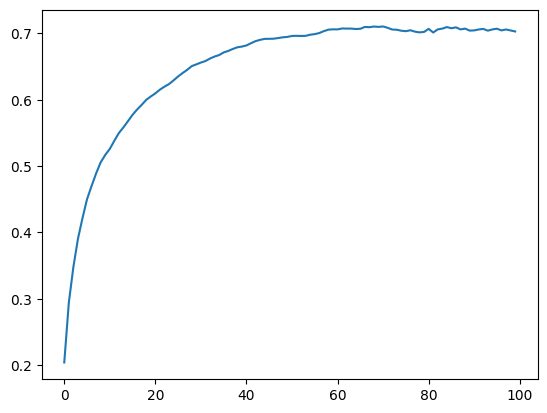

In [41]:
plt.plot(accuracy)

In [42]:
model.eval()

total = 0
total2 = 0
total3 = 0
total4 = 0
avg =0
with torch.no_grad():
    for (x,y) in test_data:
        y = y.to(device)
        x = x.to(device)
        pred = model(x)
        pred = torch.softmax(pred,dim=-1)
        pred = torch.argmax(pred,dim=-1)
        z = (y == pred).reshape(-1)
        total+=z.sum()
        z = z.reshape(-1,10)
        total2 += torch.where(torch.sum(z,dim = -1) == 10, 1,0).sum()
        total3 += torch.where(abs(torch.sum(z,dim = -1)-10)<=1, 1,0).sum()
        total4 += torch.where(abs(torch.sum(z,dim = -1)-10)<=2, 1,0).sum()
        avg += abs(torch.sum(z,dim = -1)-10).sum()

print("Test Accuracy (%):",total/test_size/10*100)
print("Full sequence correct (%):",total2/test_size*100)
print("Atmost 1 incorect sequence correct (%):",total3/test_size*100)
print("Atmost 2 incorect sequence correct (%):",total4/test_size*100)
print("Average no of rank predicted incorect in a sequence :",avg/test_size)

Test Accuracy (%): tensor(58.1100, device='cuda:0')
Full sequence correct (%): tensor(0.8000, device='cuda:0')
Atmost 1 incorect sequence correct (%): tensor(4.0000, device='cuda:0')
Atmost 2 incorect sequence correct (%): tensor(15.0000, device='cuda:0')
Average no of rank predicted incorect in a sequence : tensor(4.1890, device='cuda:0')


In [43]:
with torch.no_grad():
    for i in range(4,50,5):
        (x,y) = test_dataset[i]
        x = x.to(device).reshape(1,10)
        pred = model(x)
        pred = pred.reshape(10,10).cpu()
        pred = torch.argmax(pred,dim=-1).reshape(-1)
        print(f"{i+1} testcase")
        print("x : ",x.cpu().numpy())
        print("pred : ",pred.numpy())
        print("true : ",y)

5 testcase
x :  [[-0.7412532   1.6795137   0.69618386 -0.6797951  -1.0553725   1.3927093
  -1.17146     0.20451896 -0.44761992  0.12257481]]
pred :  [2 9 7 2 0 8 0 5 3 5]
true :  tensor([2, 9, 7, 3, 1, 8, 0, 6, 4, 5])
10 testcase
x :  [[-0.19773103 -1.0545657   0.07909244  0.5931932  -0.17795794 -0.27682343
   1.7532153  -0.5997842   1.3445711  -1.4632097 ]]
pred :  [4 1 5 6 4 4 9 3 8 0]
true :  tensor([4, 1, 6, 7, 5, 3, 9, 2, 8, 0])
15 testcase
x :  [[-0.7235851  -0.16007075 -0.92367357 -0.41732734  2.2777414  -0.6174158
   0.3911933  -0.02531732 -0.81750417  1.0159594 ]]
pred :  [3 4 0 4 9 3 6 5 2 7]
true :  tensor([2, 5, 0, 4, 9, 3, 7, 6, 1, 8])
20 testcase
x :  [[ 0.9472598  -0.11623449  1.7516979  -1.1933633  -1.1320078   0.6711603
   0.41551265 -0.16736402 -1.2853965   0.10873545]]
pred :  [7 4 9 0 0 6 6 4 0 5]
true :  tensor([8, 4, 9, 1, 2, 7, 6, 3, 0, 5])
25 testcase
x :  [[-0.6227921   0.5958571  -0.81002396  0.5235922  -1.5162493  -1.4012824
   0.5728637   1.3677777   0.51702

In [44]:
class MultiHeadAttention(nn.Module):
    def __init__(self,nheads,input_dim,attention_layers,device):
        super().__init__()
        self.device = device
        self.W_Q = nn.Parameter(torch.randn((input_dim,attention_layers*nheads))/input_dim**.5)
        self.W_K = nn.Parameter(torch.randn((input_dim,attention_layers*nheads))/input_dim**.5)
        self.W_V = nn.Parameter(torch.randn((input_dim,attention_layers*nheads))/input_dim**.5)
        self.W_O = nn.Parameter(torch.randn((attention_layers*nheads,attention_layers*nheads))/(attention_layers)**.5)

        self.sf = nn.Softmax(dim=-1)
        self.attention_layers = attention_layers
        self.nheads = nheads

    def forward(self,x):
        batchsize, input_len = x.shape[0],x.shape[1]
        Q = x@self.W_Q
        K = x@self.W_K
        V = x@self.W_V

        """
        previous attempt
        Qs = torch.chunk(Q,self.nheads,dim = -1)
        Ks = torch.chunk(K,self.nheads,dim = -1)
        Vs = torch.chunk(V,self.nheads,dim = -1)
        c = torch.concat([self.scaledDotProduct(Qs[i],Ks[i],Vs[i]) for i in range(self.nheads)],dim=-1)
        return c@self.W_O
        """
        
        Qs = Q.reshape(batchsize,input_len,self.nheads,self.attention_layers).transpose(1,2)
        Ks = K.reshape(batchsize,input_len,self.nheads,self.attention_layers).transpose(1,2)
        Vs = V.reshape(batchsize,input_len,self.nheads,self.attention_layers).transpose(1,2)

        out = self.scaledDotProduct(Qs,Ks,Vs).transpose(1,2).reshape(batchsize,input_len,-1)
        return out@self.W_O
        

    def scaledDotProduct(self,Q,K,V):
        return self.sf(1/torch.sqrt(torch.Tensor([Q.shape[-1]]).to(self.device))*(Q@(K.transpose(-1,-2))))@V

In [45]:
class EncoderOnlyTransformerPredictor2(torch.nn.Module):
    def __init__(self,device):
        super().__init__()
        self.device = device
        self.att = MultiHeadAttention(4,2,16,device)
        self.norm = AddAndNormalise()
        self.W_1 = nn.Parameter(torch.randn((4*16+2,64))/66**0.5)
        self.b_1 = nn.Parameter(torch.randn(64)*0.1)
        self.W_2 = nn.Parameter(torch.randn((64,10))/8)
        self.b_2 = nn.Parameter(torch.randn(10)*0.1)
        self.r = nn.ReLU()
        self.ff = lambda x : self.r(x@self.W_1+self.b_1)@self.W_2 + self.b_2

    def forward(self,x):
        x2 = self.position_embedded(x)
        x3 = self.att(x2)
        x4 = self.norm(x2,x3)
        
        x5 = self.ff(x4)
        return x5

    def position_embedded(self,x):
        x = x.reshape(-1,x.shape[1],1)
        P = torch.zeros_like(x)
        for i in range(x.shape[1]):
            P[:,i,0] = (1.5)**(-i)
            #P[:,i,0] = np.sin(i)
        return torch.concat([x,P], dim = -1)


In [46]:
max_epochs = 200
learning_rate = 1e-3

device = "cuda:0" if torch.cuda.is_available() else "cpu"
#device = "cpu"
model = EncoderOnlyTransformerPredictor2(device)
model.to(device)
loss_fn = nn.CrossEntropyLoss()

opt = torch.optim.AdamW(model.parameters(),lr = learning_rate)

model.train()
accuracies = []
losses = []
for i in range(max_epochs):
    s = 0
    for (x,y) in train_data:
        x = x.to(device)
        y = y.to(device)
        pred = model(x)
        pred = pred.transpose(1,2)
        loss = loss_fn(pred,y)
        losses.append(loss.item())
        loss.backward()
        s+=loss.item()
        opt.step()
        opt.zero_grad()
    with torch.no_grad():
        total = 0
        for (x,y) in valid_data:
            x = x.to(device)
            y = y.to(device)
            pred = model(x)
            pred = torch.softmax(pred,dim=-1)
            pred = torch.argmax(pred,dim=-1)
            z = (y == pred).reshape(-1)
            #z = torch.where(z <= 0.5*4/33, 1,0)
            total += z.sum()
    accuracies.append((total/valid_size/10))
    if (i%10 == 0):
        print(accuracies[-1])

tensor(0.5538, device='cuda:0')
tensor(0.6080, device='cuda:0')
tensor(0.6732, device='cuda:0')
tensor(0.6930, device='cuda:0')
tensor(0.7008, device='cuda:0')
tensor(0.7076, device='cuda:0')
tensor(0.7122, device='cuda:0')
tensor(0.7212, device='cuda:0')
tensor(0.7291, device='cuda:0')
tensor(0.7327, device='cuda:0')
tensor(0.7338, device='cuda:0')
tensor(0.7339, device='cuda:0')
tensor(0.7374, device='cuda:0')
tensor(0.7375, device='cuda:0')
tensor(0.7420, device='cuda:0')
tensor(0.7444, device='cuda:0')
tensor(0.7443, device='cuda:0')
tensor(0.7479, device='cuda:0')
tensor(0.7470, device='cuda:0')
tensor(0.7474, device='cuda:0')


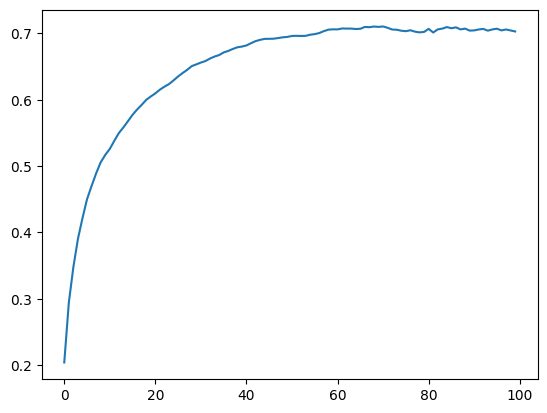

In [48]:
plt.plot(accuracy)

In [49]:
model.eval()

total = 0
total2 = 0
total3 = 0
total4 = 0
avg =0
with torch.no_grad():
    for (x,y) in test_data:
        y = y.to(device)
        x = x.to(device)
        pred = model(x)
        pred = torch.softmax(pred,dim=-1)
        pred = torch.argmax(pred,dim=-1)
        z = (y == pred).reshape(-1)
        total+=z.sum()
        z = z.reshape(-1,10)
        total2 += torch.where(torch.sum(z,dim = -1) == 10, 1,0).sum()
        total3 += torch.where(abs(torch.sum(z,dim = -1)-10)<=1, 1,0).sum()
        total4 += torch.where(abs(torch.sum(z,dim = -1)-10)<=2, 1,0).sum()
        avg += abs(torch.sum(z,dim = -1)-10).sum()

print("Test Accuracy (%):",total/test_size/10*100)
print("Full sequence correct (%):",total2/test_size*100)
print("Atmost 1 incorect sequence correct (%):",total3/test_size*100)
print("Atmost 2 incorect sequence correct (%):",total4/test_size*100)
print("Average no of rank predicted incorect in a sequence :",avg/test_size)

Test Accuracy (%): tensor(74.8400, device='cuda:0')
Full sequence correct (%): tensor(4.9000, device='cuda:0')
Atmost 1 incorect sequence correct (%): tensor(22.6000, device='cuda:0')
Atmost 2 incorect sequence correct (%): tensor(51.6000, device='cuda:0')
Average no of rank predicted incorect in a sequence : tensor(2.5160, device='cuda:0')


In [50]:
with torch.no_grad():
    for i in range(4,50,5):
        (x,y) = test_dataset[i]
        x = x.to(device).reshape(1,10)
        pred = model(x)
        pred = pred.reshape(10,10).cpu()
        pred = torch.argmax(pred,dim=-1).reshape(-1)
        print(f"{i+1} testcase")
        print("x : ",x.cpu().numpy())
        print("pred : ",pred.numpy())
        print("true : ",y)

5 testcase
x :  [[-0.7412532   1.6795137   0.69618386 -0.6797951  -1.0553725   1.3927093
  -1.17146     0.20451896 -0.44761992  0.12257483]]
pred :  [2 9 7 3 1 8 0 6 4 6]
true :  tensor([2, 9, 7, 3, 1, 8, 0, 6, 4, 5])
10 testcase
x :  [[-0.19773103 -1.0545657   0.07909244  0.5931932  -0.17795794 -0.27682343
   1.7532153  -0.5997842   1.3445711  -1.4632097 ]]
pred :  [4 1 6 7 4 4 9 3 8 0]
true :  tensor([4, 1, 6, 7, 5, 3, 9, 2, 8, 0])
15 testcase
x :  [[-0.7235851  -0.16007075 -0.92367357 -0.41732734  2.2777414  -0.6174158
   0.3911933  -0.02531733 -0.81750417  1.0159594 ]]
pred :  [1 5 0 4 9 3 7 5 1 8]
true :  tensor([2, 5, 0, 4, 9, 3, 7, 6, 1, 8])
20 testcase
x :  [[ 0.9472598  -0.11623449  1.7516979  -1.1933633  -1.1320078   0.6711603
   0.41551265 -0.16736402 -1.2853965   0.10873545]]
pred :  [8 4 9 1 1 7 6 4 0 5]
true :  tensor([8, 4, 9, 1, 2, 7, 6, 3, 0, 5])
25 testcase
x :  [[-0.6227921   0.5958571  -0.81002396  0.5235922  -1.5162493  -1.4012824
   0.5728637   1.3677777   0.51702